In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("healthcare-dataset-stroke-data.csv")
print(df.shape)
print(df.head())


(5110, 12)
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [9]:
df.info()
df['stroke'].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


stroke
0    4861
1     249
Name: count, dtype: int64

In [13]:
#numeric distributions
df[['age', 'avg_glucose_level', 'bmi']].describe()
# print(df['age'].head(10).tolist())
# print(df['hypertension'].head(10).tolist())

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


visualization

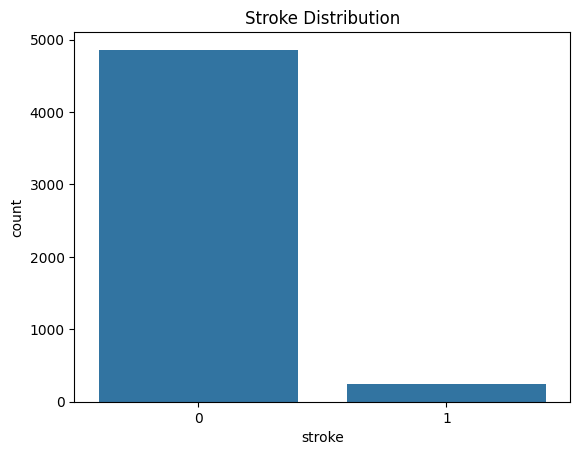

In [14]:
sns.countplot(x="stroke",data=df)
plt.title("Stroke Distribution")
plt.show()

Encoding Categorical values as models need numers not text 

In [18]:
for col in ['gender','ever_married','work_type','Residence_type',"smoking_status"]:
    print(col,":",df[col].unique())

gender : <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
ever_married : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
work_type : <StringArray>
['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked']
Length: 5, dtype: str
Residence_type : <StringArray>
['Urban', 'Rural']
Length: 2, dtype: str
smoking_status : <StringArray>
['formerly smoked', 'never smoked', 'smokes', 'Unknown']
Length: 4, dtype: str


In [42]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
# Fill missing BMI
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

# Drop the 1 'Other' gender row
df = df[df['gender'] != 'Other']

# Now do the binary encoding 
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['ever_married'] = df['ever_married'].map({'Yes': 1, 'No': 0})
df['Residence_type'] = df['Residence_type'].map({'Urban': 1, 'Rural': 0})
df.head()
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [43]:
#one hot encoding for multicategory columns
df=pd.get_dummies(df,columns=['work_type','smoking_status'],drop_first=True)
df.columns.tolist()

['id',
 'gender',
 'age',
 'hypertension',
 'heart_disease',
 'ever_married',
 'Residence_type',
 'avg_glucose_level',
 'bmi',
 'stroke',
 'work_type_Never_worked',
 'work_type_Private',
 'work_type_Self-employed',
 'work_type_children',
 'smoking_status_formerly smoked',
 'smoking_status_never smoked',
 'smoking_status_smokes']

In [44]:
df.dtypes

id                                  int64
gender                              int64
age                               float64
hypertension                        int64
heart_disease                       int64
ever_married                        int64
Residence_type                      int64
avg_glucose_level                 float64
bmi                               float64
stroke                              int64
work_type_Never_worked               bool
work_type_Private                    bool
work_type_Self-employed              bool
work_type_children                   bool
smoking_status_formerly smoked       bool
smoking_status_never smoked          bool
smoking_status_smokes                bool
dtype: object

correlation hetamap:shows how all numeric variables relate to each other,including to stroke

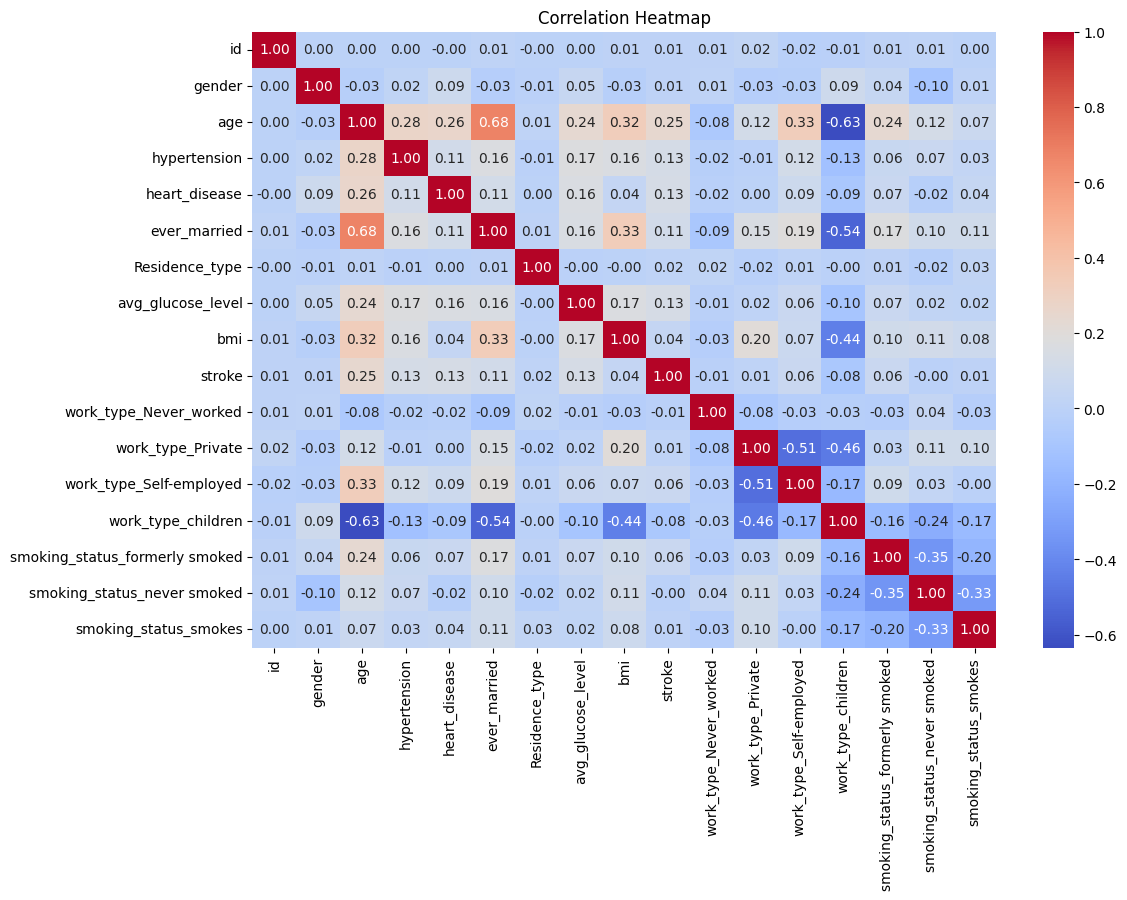

In [51]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,fmt='.2f',cmap='coolwarm' )
plt.title('Correlation Heatmap')
plt.show()

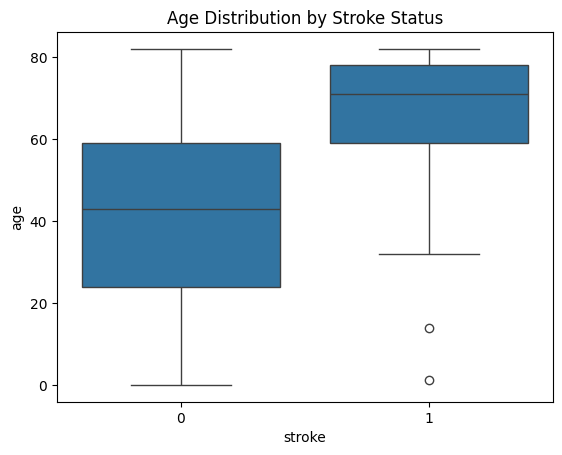

In [48]:
sns.boxplot(x='stroke',y='age',data=df)
plt.title('Age Distribution by Stroke Status')
plt.show()

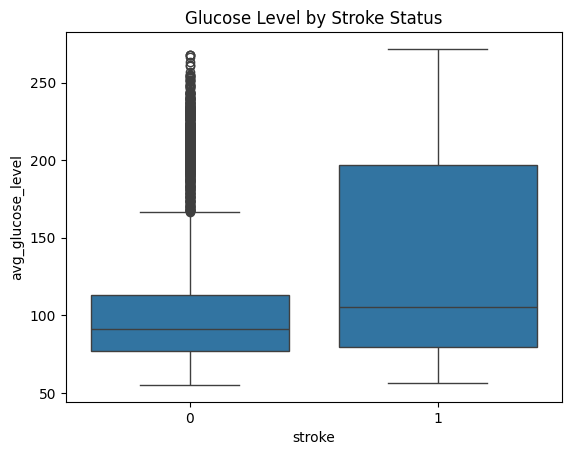

In [49]:
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)
plt.title('Glucose Level by Stroke Status')
plt.show()

In [50]:
pd.crosstab(df['hypertension'], df['stroke'], normalize='index')

stroke,0,1
hypertension,,
0,0.960312,0.039688
1,0.867470,0.132530


In [54]:
#modeling

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,accuracy_score


X=df.drop(["id","stroke"],axis=1)
y=df["stroke"]

X_train,X_test ,y_train ,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(X_train.shape,X_test.shape)

model=LogisticRegression(max_iter=1000,class_weight="balanced")
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print(classification_report(y_test,y_pred))
print("accuracy",accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

(4087, 15) (1022, 15)
              precision    recall  f1-score   support

           0       0.99      0.74      0.84       972
           1       0.13      0.80      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.74      0.81      1022

accuracy 0.738747553816047
[[715 257]
 [ 10  40]]
ROC-AUC: 0.8392798353909464


In [59]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

ROC-AUC: 0.784619341563786


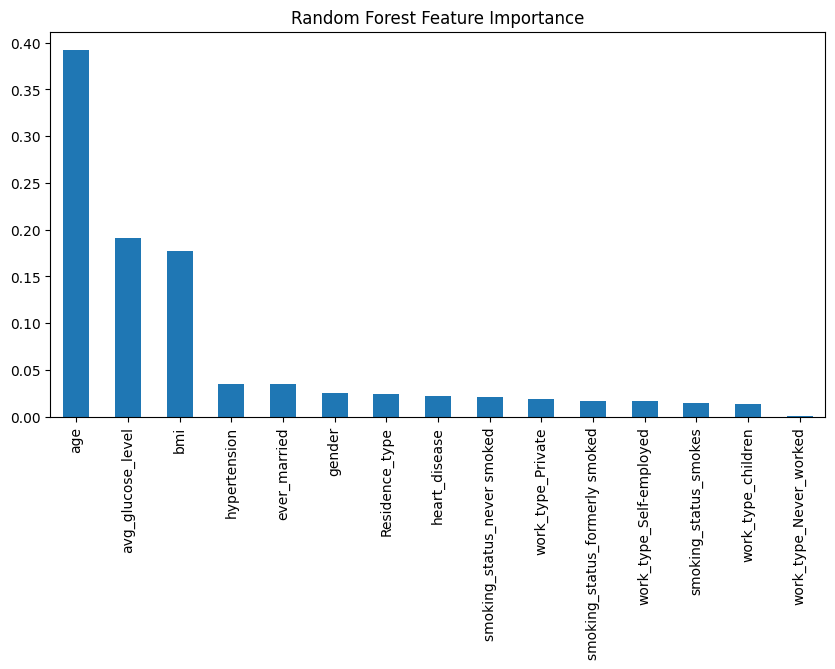

In [56]:
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 5))
plt.title('Random Forest Feature Importance')
plt.show()

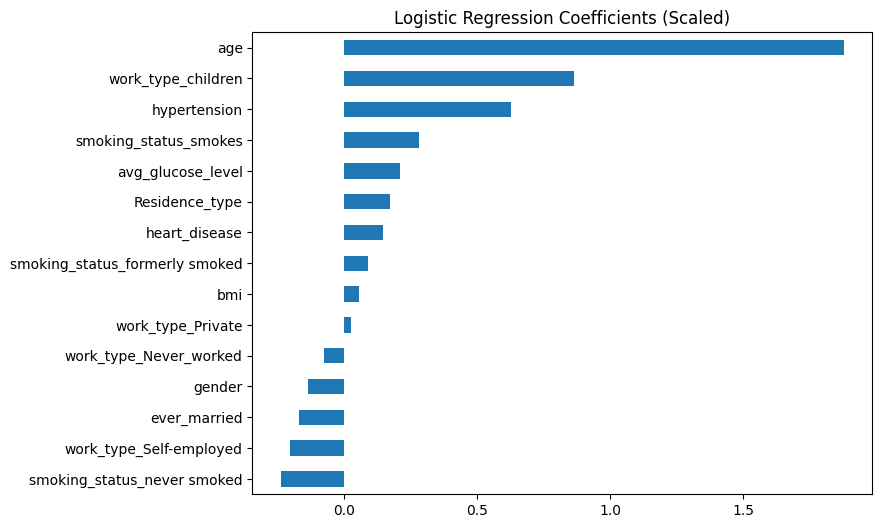

In [58]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_cols = ['age', 'avg_glucose_level', 'bmi']
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

model_scaled = LogisticRegression(max_iter=1000, class_weight='balanced')
model_scaled.fit(X_train_scaled, y_train)

coefficients = pd.Series(model_scaled.coef_[0], index=X_train.columns)
coefficients.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Logistic Regression Coefficients (Scaled)')
plt.show()

Summary of Findings

1.The dataset was highly imbalanced, with only about 5% of patients having a stroke. Because of this, accuracy alone was not a reliable measure of model performance.

2.Logistic Regression with class_weight='balanced' performed well at identifying stroke cases. It achieved an 80% recall and a ROC-AUC score of 0.84, although its precision was only 13% because it produced more false positive predictions.

3.Random Forest achieved a high accuracy of 95%, but it failed to identify any actual stroke cases, resulting in a recall of 0%. This shows why accuracy can be misleading when working with imbalanced datasets.

3.Feature scaling was important for interpreting the Logistic Regression model. Before scaling, some coefficients appeared more important simply because of differences in feature values. After scaling, both Logistic Regression and Random Forest identified age as the most important predictor, which is consistent with medical knowledge.

4.Hypertension also showed a strong relationship with stroke risk. Patients with hypertension had a stroke rate that was approximately 3.3 times higher than those without hypertension.